# Data Preprocessing Techniques

### 🛠️ Ye Kya Hai aur Kyu Use Hota Hai? (The Problem & Solution)
* **Problem:** Real-world me jo raw data (kachha data) hume milta hai, wo bohot messy, incomplete, aur unorganized hota hai. Agar hum direct is data ko Machine Learning model me daal denge, to model achhe se seekh nahi payega aur galat predictions dega ("Garbage In, Garbage Out").
* **Solution:** **Data Preprocessing** workflow ka wo sabse pehla aur zaroori step hai jahan raw data par alag-alag transformations apply kiye jaate hain. Iska main maqsad data ko is kabil banana hai ki ML models usse aasan bhasha me samajh sakein aur pattern pakad sakein. Ye hamesha model training ya prediction se **pehle** kiya jata hai.

---

### 💼 Kaha Use Hoga? (Real-World Use Cases)
1. **Har Ek ML Project me:** Data chaho jaisa bhi ho (numbers, text, ya dates), bina preprocessing ke koi bhi model industry me deploy nahi kiya jata.
2. **Feature Engineering me:** Jab aapko data ka structure badalna ho, extra informational features banane hon, ya bekar ke columns ko remove karna ho.

---

### ⚙️ Ye Kaam Kaise Karta Hai? (Working Principle & Flow)
* Data Preprocessing ko alag-alag stages me banta jata hai: pehle data saaf kiya jata hai (**Cleaning**), fir usko badla jata hai (**Transformation**), uske baad best features chune jaate hain (**Selection/Extraction**).
* In saare transformations ko ek specific order (sequence) me chalane ke liye hum `Pipeline` ka use karte hain.
* Agar alag-alag columns par alag preprocessing karni ho, to hum `FeatureUnion` ya `ColumnTransformer` ka use karke unke outputs ko ek sath single matrix me merge kar dete hain.

---

### 🗂️ Preprocessing Techniques: Complete Breakdown

Niche un saare methods ki list hai jo ek data scientist raw data ko sudharne ke liye use karta hai:

#### 1. Data Cleaning (Data ko Saaf Karna)
* **Data Imputation:** Agar dataset me kuch values missing hain (blank spaces), to unhe mean, median, ya mode se bharna taaki algorithm crash na ho.
* **Feature Scaling:** Alag-alag ranges wale numbers (jaise Age: 20-60 aur Salary: 20,000-1,00,000) ka scale barabar karna (StandardScaler ya MinMaxScaler se), taaki model kisi ek feature ki taraf biased na ho.

#### 2. Feature Transformation (Data ka Roop Badalka)
* **Polynomial Features:** Existing features ki powers (jaise $x^2, x^3$) ya interaction terms ($x \times y$) banakar non-linear relationships ko capture karna.
* **Discretization (Binning):** Continuous numbers ko groups ya buckets me todna (jaise Age ko 'Child', 'Teens', 'Adult' me badalna).
* **Handling Categorical Features:** Text data (jaise 'Red', 'Blue') ka mathematical representation banana (One-Hot Encoding ya Label Encoding ke zariye).
* **Custom Transformers:** Jab Scikit-Learn ke standard tools kaam nahi aate, tab hum khud ka logic lagakar apna transformer code karte hain.
* **Composite Transformers (Apply transformation to diverse features):** Alag-alag data types (numerical aur categorical) par unke hisab se ek sath composite transformations lagana.
* **TargetTransformedRegressor:** Sirf input features par hi nahi, balki target variable ($y$) par bhi transformation lagana (jaise Log Transform) aur prediction ke waqt use automatic wapas reverse (inverse transform) karna.

#### 3. Feature Selection (Sabse Best Columns Chunna)
* **Filter-based:** Statistical tests (jaise Correlation, Chi-Square) ka use karke bad features ko pehle hi drop kar dena, bina model ko involve kiye.
* **Wrapper-based:** Model ko baar-baar train karke check karna ki kaun sa feature subset best accuracy de raha hai (jaise Forward/Backward selection).

#### 4. Feature Extraction (Naye Matrix me Summary Banana)
* **PCA (Principal Component Analysis):** Agar aapke paas 100 features hain, to PCA unhe compress karke 5 ya 10 aise naye main components me badal deta hai jisme maximum information retained rehti hai.

---

### 👁️ Pipeline Automation & Visualization
In saare steps ko sahi order me set karne ke liye hum **Pipeline** aur **FeatureUnion** ka framework khada karte hain. Aaj kal modern tools (jaise Scikit-Learn ka HTML display) hume in poori pipelines ko visual interactive diagrams me dekhne aur debug karne ki suvidha dete hain.


#### Improting Basic Liberaries

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
sns.set_theme(style="whitegrid")

## 1. Feature Extraction

### 1.1 Dict Vectorizer

Many a times the data is present as a `list of dictionary objects`. ML algorithms expect the data in matrix form with shape (n, m) where n is the number of samples and m is the number of features.
`DictVectorizer` converts a list of dictionary objects to feature matrix.

In [129]:
from sklearn.feature_extraction import DictVectorizer

data = [
    {'age': 4, 'height':96.0},
    {'age': 1, 'height': 73.9},
    {'age': 3, 'height': 88.9},
    {'age': 2, 'height': 81.6}
]


dv = DictVectorizer(sparse=False)
data_transformed = dv.fit_transform(data)
data_transformed

array([[ 4. , 96. ],
       [ 1. , 73.9],
       [ 3. , 88.9],
       [ 2. , 81.6]])

### 1.2 Data Imputation

# Data Imputation (Handling Missing Data)

### 🛠️ Ye Kya Hai aur Kyu Use Hota Hai? (The Problem & Solution)
* **Problem:** Zyadatar Machine Learning algorithms ko ek completely bhara hua data matrix chahiye hota hai. Agar aapke dataset me kuch values missing (khali ya `NaN`) hain, to ML model crash ho jayega aur kaam nahi karega.
* **Solution:** **Data Imputation** ek aisi technique hai jo dataset me un khali (missing) jagahon ko dhundhti hai aur unhe kisi logical value se bhar deti hai (jaise us column ka average nikal kar wahan daal dena). Isse aapka data model training ke liye ready ho jata hai.

---

### 💼 Kaha Use Hoga? (Real-World Use Cases)
1. **Incomplete Datasets me:** Jab aap real-world data par kaam karte hain, to aksar log forms me kuch fields (jaise Age, Salary, ya Feedback) khali chhod dete hain. Un khali jagahon ko fix karne ke liye.
2. **Data Cleaning Pipeline me:** ML model me raw data bhejne se theek pehle, pipeline ke andar data clean karne ke liye.

---

### ⚙️ Ye Kaam Kaise Karta Hai? (Working Principle)
Scikit-Learn me is kaam ke liye `sklearn.impute.SimpleImputer` class ka use kiya jata hai. Ye class ek fix strategy (jaise mean, median, ya mode) ko follow karke pure column ke hisab se missing values ko replace kar deti hai.

**Kuch Important Parameters:**

1. **`missing_values`:** Ye imputer ko batata hai ki data me missing value kis roop me hai. (Example: `np.nan`, `None`, ya koi integer/string). Default value `np.nan` hoti hai.
2. **`strategy`:** Ye sabse main parameter hai jo batata hai ki khali jagah me **kya bharna hai**. Iske 4 options hote hain:
   * `"mean"` - Column ki sabhi values ka Average nikal kar khali jagah me bhar dega.
   * `"median"` - Column ki middle value (Median) nikal kar bharega (Outliers se bachne ke liye best hai).
   * `"most_frequent"` - Column me jo value sabse zyada baar aayi hai (Mode), use bharega (Categorical/Text data ke liye best hai).
   * `"constant"` - Aapki di gayi ek fix value bharega (Iske liye `fill_value` argument dena padta hai).
3. **`add_indicator`:** Agar ise `True` set karte hain, to ye ek extra column bana kar bata deta hai ki data me kahan-kahan original value thi aur kahan-kahan humne nayi value bhari hai (indicator variable ki madad se).

---

### 💻 Code Example

```python
import numpy as np
from sklearn.impute import SimpleImputer

# Maan lijiye ye hamara data hai jisme 'np.nan' missing values hain
data = [[7, 2, 3], 
        [4, np.nan, 6], 
        [10, 5, 9]]

# 1. Imputer object banayein (strategy = mean rakh rahe hain)
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

# 2. Data ko fit aur transform karein
transformed_data = imputer.fit_transform(data)

print(transformed_data)
# Output me dekhenge ki 'np.nan' ki jagah (2+5)/2 = 3.5 bhar gaya hai.

In [130]:
import numpy as np
from sklearn.impute import SimpleImputer

# Maan lijiye ye hamara data hai jisme 'np.nan' missing values hain
data = [[7, 2, 3], 
        [4, np.nan, 6], 
        [10, 5, 9]]

# 1. Imputer object banayein (strategy = mean rakh rahe hain)
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

# 2. Data ko fit aur transform karein
transformed_data = imputer.fit_transform(data)

print(transformed_data)
# Output me dekhenge ki 'np.nan' ki jagah (2+5)/2 = 3.5 bhar gaya hai.

[[ 7.   2.   3. ]
 [ 4.   3.5  6. ]
 [10.   5.   9. ]]


## Data Imputation On Real World Dataset

In [131]:
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg','thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
# Data Loading
heart_data = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data', 
    header=None, 
    names=cols
)

In [132]:
heart_data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [133]:
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [134]:
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [135]:
# Categorizing unique values
print(f"Unique Values in ca: {heart_data.ca.unique()}")
print(f"Unique Values in thal: {heart_data.thal.unique()}")

Unique Values in ca: <StringArray>
['0.0', '3.0', '2.0', '1.0', '?']
Length: 5, dtype: str
Unique Values in thal: <StringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str


In [136]:
# Counting how many times '?' occurs 
print(f"Missing Values in ca:- '\n'{heart_data.loc[heart_data.ca == '?' , 'ca'].count()}")
print(f"Missing Values in thal:- '\n'{heart_data.loc[heart_data.thal=='?' , 'thal'].count()}")

Missing Values in ca:- '
'4
Missing Values in thal:- '
'2


In [137]:
# Replacing '?' with NaN

heart_data.replace('?' , np.nan , inplace=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [138]:
# Imputing NaN Values

si = SimpleImputer(missing_values=np.nan , strategy = "mean")
heart_data_imputed = si.fit_transform(heart_data)
print(heart_data_imputed.shape)

(303, 14)


## 2. Feature Scaling

# Feature Scaling

### 🛠️ Ye Kya Hai aur Kyu Use Hota Hai? (The Problem & Solution)
* **Problem:** Real-world datasets me alag-alag columns (features) ki ranges bohot alag hoti hain. Maan lijiye ek column hai `Age` (range: 20 se 60) aur doosra hai `Salary` (range: 20,000 se 1,00,000). Machine Learning models mukhya roop se mathematics par chalte hain, isliye wo `Salary` ke bade numbers ko galti se zyada important maan lenge aur `Age` ko ignore kar denge. 
* **Solution:** **Feature Scaling** sabhi features ko daba kar ek common aur barabar scale par le aata hai (jaise 0 se 1 ke beech). Isse sabhi columns ki importance model ki nazron me barabar ho jati hai.

---

### 🚀 Scaling Ke Fayde (Advantages)
1. **Faster Convergence:** Deep Learning aur Linear models me 'Gradient Descent' naam ka optimization algorithm lagta hai. Agar data scaled ho, to ye algorithm bohot tezi se apna answer (global minima) dhundh leta hai, jisse model ki training speed badh jati hai.
2. **Improves Distance-Based Algorithms:** Jo algorithms data points ke beech ki doori (Euclidean distance) naap kar kaam karte hain, unke liye scaling **mandatory (zaroori)** hai. Agar aap bina scaling ke in models ko chalayenge, to bade numbers wale features poori distance ko dominate kar lenge.
   * *Examples:* Support Vector Machines (SVM), K-Nearest Neighbors (K-NN), aur K-Means Clustering.

---

### 🛑 Kaha Scaling Ki Zaroorat NAHI Hai? (Exceptions)
* **Tree-based ML Algorithms** par feature scaling ka koi asar nahi padta. 
* Decision Trees, Random Forest, aur XGBoost algorithms numbers ke beech ki doori nahi naapte; wo data ko rules/conditions ke hisab se todte hain (jaise *kya age > 30 hai?*). Isliye in models ko raw data par direct chalaya ja sakta hai.

---

### ⚙️ Feature Scaling Ke Tarike (Methods in Scikit-Learn)
Data ko scale karne ke teen sabse popular tarike (transformers) hote hain:

1. **Standardization (`StandardScaler`):** Ye mean ko `0` aur standard deviation ko `1` bana deta hai. (Sabse zyada yahi use hota hai, aur outliers par thoda stable rehta hai).
2. **Normalization (`MinMaxScaler`):** Ye pure data ko strictly `0` aur `1` ke beech me squeeze kar deta hai.
3. **MaxAbsScaler:** Ye data ko `-1` aur `1` ke beech me scale karta hai, bina data ke center (0) ko shift kiye. Sparse data ke liye bohot useful hai.

In [139]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [140]:
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    str    
 12  thal      301 non-null    str    
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


### 2.1 MaxAbsScaler

In [141]:
from sklearn.preprocessing import MaxAbsScaler

col="chol"
mas = MaxAbsScaler()

mas_scaled = mas.fit_transform(heart_data[[col]])
mas_scaled[:5]

array([[0.41312057],
       [0.5070922 ],
       [0.40602837],
       [0.44326241],
       [0.36170213]])

### 2.3 Standard Scaler

In [142]:
from sklearn.preprocessing import StandardScaler

col = "chol"

ss = StandardScaler()

ss_scaled = ss.fit_transform(heart_data[[col]])

ss_scaled[:10]

array([[-0.2649003 ],
       [ 0.76041519],
       [-0.34228261],
       [ 0.06397448],
       [-0.82592199],
       [-0.20686358],
       [ 0.41219483],
       [ 2.07591432],
       [ 0.14135678],
       [-0.84526757]])

### 2.2 MinMaxScaler

In [143]:
from sklearn.preprocessing import MinMaxScaler

col="chol"

min_max_scaler = MinMaxScaler()

mm_scaler_scaled = min_max_scaler.fit_transform(heart_data[[col]])

mm_scaler_scaled[:10]

array([[0.24429224],
       [0.3652968 ],
       [0.23515982],
       [0.28310502],
       [0.17808219],
       [0.25114155],
       [0.32420091],
       [0.52054795],
       [0.29223744],
       [0.17579909]])

## 3. Visualization of Feature Distribution

* `Histogram`
* `Kernel density estimation (KDE) plot`
* `Box`
* `Violin`

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn ka ek default dataset 'tips' load kar rahe hain
data = sns.load_dataset('tips') 
# Is dataset me columns hain: total_bill, tip, sex, smoker, day, time, size

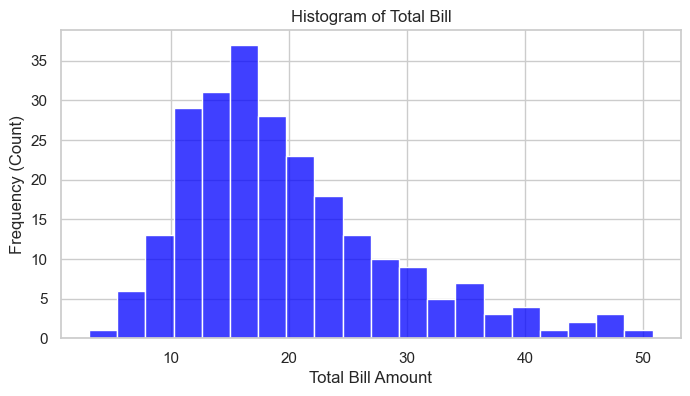

In [145]:
# 1. Histogram

plt.figure(figsize=(8, 4))
# 'total_bill' column ka histogram bana rahe hain
sns.histplot(data['total_bill'], bins=20, color='blue')
plt.title('Histogram of Total Bill')
plt.xlabel('Total Bill Amount')
plt.ylabel('Frequency (Count)')
plt.show()

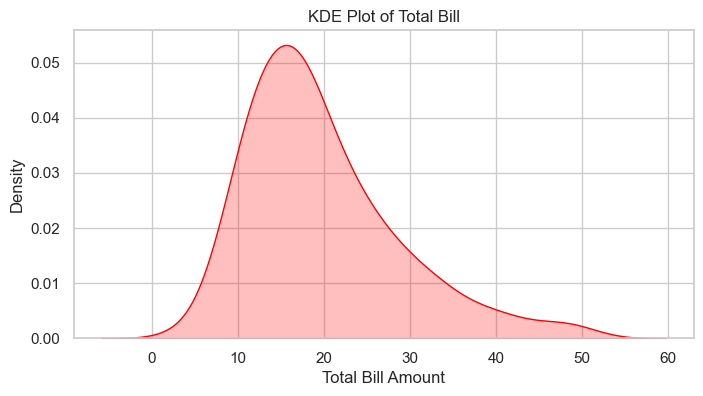

In [146]:
# 2. Kernel Density Estimation (KDE) Plot

plt.figure(figsize=(8, 4))
# 'total_bill' ka KDE (smooth curve) plot
sns.kdeplot(data['total_bill'], fill=True, color='red')
plt.title('KDE Plot of Total Bill')
plt.xlabel('Total Bill Amount')
plt.ylabel('Density')
plt.show()

C:\Users\sumit\AppData\Local\Temp\ipykernel_28324\1235694028.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='total_bill', data=data, palette='Set2')


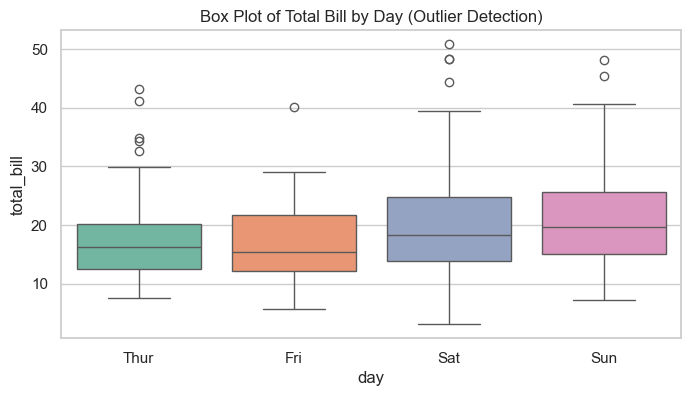

In [147]:
# 3. Box plot

plt.figure(figsize=(8, 4))
# X-axis par din (day) aur Y-axis par bill amount dekh rahe hain
sns.boxplot(x='day', y='total_bill', data=data, palette='Set2')
plt.title('Box Plot of Total Bill by Day (Outlier Detection)')
plt.show()

C:\Users\sumit\AppData\Local\Temp\ipykernel_28324\2096950957.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='day', y='total_bill', data=data, palette='muted')


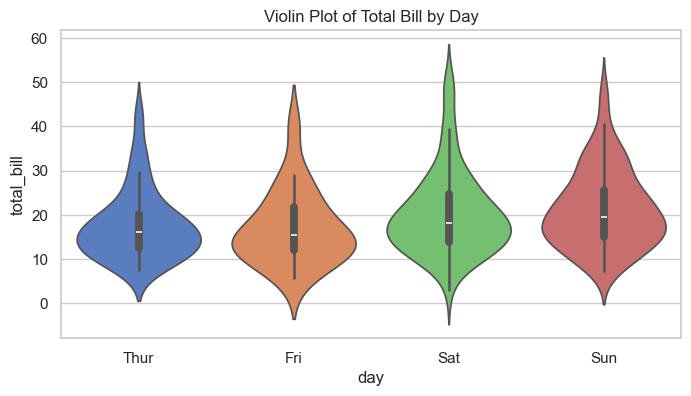

In [148]:
# 4. Violin Plot

plt.figure(figsize=(8, 4))
# Violin plot draw karna
sns.violinplot(x='day', y='total_bill', data=data, palette='muted')
plt.title('Violin Plot of Total Bill by Day')
plt.show()